# Higgs-Jagd – ein Beispiel für wissenschaftliche Forschung

Die Daten, die wir hier verwenden, sind "echte" Daten aus dem CMS-Experiment, das die Existenz dieses schwer fassbaren Teilchens bestätigte. Die Entdeckung durch ATLAS und CMS führte schließlich zum Nobelpreis im Jahr 2013. Anstatt eine komplett vorgefertigten Grafik yu haben, können Sie diese Daten nun selbst erkunden. Das Beispiel basiert auf dem Originalcode in [http://opendata.cern.ch/record/5500] auf dem CERN Open Data Portal (Jomhari, Nur Zulaiha; Geiser, Achim; Bin Anuar, Afiq Aizuddin; (2017). Beispiel für eine Higgs-zu-vier-Leptonen-Analyse unter Verwendung von Daten aus den Jahren 2011–2012. CERN Open Data Portal. DOI:10.7483/OPENDATA.CMS.JKB8.RR42) und der ursprünglichen „Notebook-Version” von Tom McCauley (University of Notre Dame) und Peitsa Veteli (Helsinki Institute of Physics).

Wir betrachten den verhältnismäßig hintergrundarmen Endzustand, in dem das Higgs-Boson zerfällt, in dem es zunächst zwei Z-Bosonen erzeugt, die dann weiter in vier Leptonen (Elektronen, Myonen...) zerfallen. Für das Higgs-Boson-Signal betrachten wir die invariante Massenverteilung der vier Leptonen und erwarten einen Peak über dem Hintergrund bei etwa der Masse des Higgs-Bosons.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [8]:
# Data for later use.

csvs = [pd.read_csv('../../Data/4mu_2011.csv'), pd.read_csv('../../Data/4e_2011.csv'), pd.read_csv('../../Data/2e2mu_2011.csv')]
csvs += [pd.read_csv('../../Data/4mu_2012.csv'), pd.read_csv('../../Data/4e_2012.csv'), pd.read_csv('../../Data/2e2mu_2012.csv')]

fourlep = pd.concat(csvs)

In [9]:
# Choose a mass region to analyse the experimental data and create a histogram of the invariant mass distribution from the input

rmin = 70
rmax = 181
nbins = 37

M_hist = np.histogram(fourlep['M'], bins = nbins, range = (rmin,rmax))

hist, bins = M_hist
width = 1.0*(bins[1] - bins[0])
center = (bins[:-1] + bins[1:]) / 2

Der Einfachheit halber verwenden wir vorsimulierte Werte für Hintergrundereignisse (und Higgs-Signale), die bereits nach Luminosität, Wirkungsquerschnitt und Anzahl der Ereignisse gewichtet wurden. Im Grunde erstellen wir einen Satz von Werten, die eine gewisse Zufälligkeit aufweisen, genau wie bei einer realen Messung, aber der Verteilung folgen, die in diesen Prozessen beobachtet wurde.

In [10]:
# DY, some irreducible background from singular Z bosons.
dy = np.array([0,0,0,0,0,0.354797,0.177398,2.60481,0,0,0,0,0,0,0,0,0,0.177398,0.177398,0,0.177398,0,0,0,0,0,0,0,0,0,0,0,0.177398,0,0,0,0])
# ttbar, a pair of top and anti-top quarks.
ttbar = np.array([0.00465086,0,0.00465086,0,0,0,0,0,0,0,0.00465086,0,0,0,0,0,0.00465086,0,0,0,0,0.00465086,0.00465086,0,0,0.0139526,0,0,0.00465086,0,0,0,0.00465086,0.00465086,0.0139526,0,0])
# ZZ, a pair of "real" Z bosons.
zz = np.array([0.181215,0.257161,0.44846,0.830071,1.80272,4.57354,13.9677,14.0178,4.10974,1.58934,0.989974,0.839775,0.887188,0.967021,1.07882,1.27942,1.36681,1.4333,1.45141,1.41572,1.51464,1.45026,1.47328,1.42899,1.38757,1.33561,1.3075,1.29831,1.31402,1.30672,1.36442,1.39256,1.43472,1.58321,1.85313,2.19304,2.95083])
#our Higgs signal for a specific mass of the Higgs boson
hzz = np.array([0.00340992,0.00450225,0.00808944,0.0080008,0.00801578,0.0108945,0.00794274,0.00950757,0.0130648,0.0163568,0.0233832,0.0334813,0.0427229,0.0738129,0.13282,0.256384,0.648352,2.38742,4.87193,0.944299,0.155005,0.0374193,0.0138906,0.00630364,0.00419265,0.00358719,0.00122527,0.000885718,0.000590479,0.000885718,0.000797085,8.86337e-05,0.000501845,8.86337e-05,0.000546162,4.43168e-05,8.86337e-05])


Hier ist der Großteil der Arbeit bereits für Sie erledigt:
Führen Sie die Zelle aus, um die invariante Massenverteilung der hier betrachteten Hintergrundprozesse zu betrachten. Warum sehen wir einen Peak bei etwa 90 GeV?

In einem zweiten Schritt: Hier wurde der Eintrag für „Gemessene Daten” schon erledigt. Wie gut stimmen die Daten mit den Erwartungen überein?

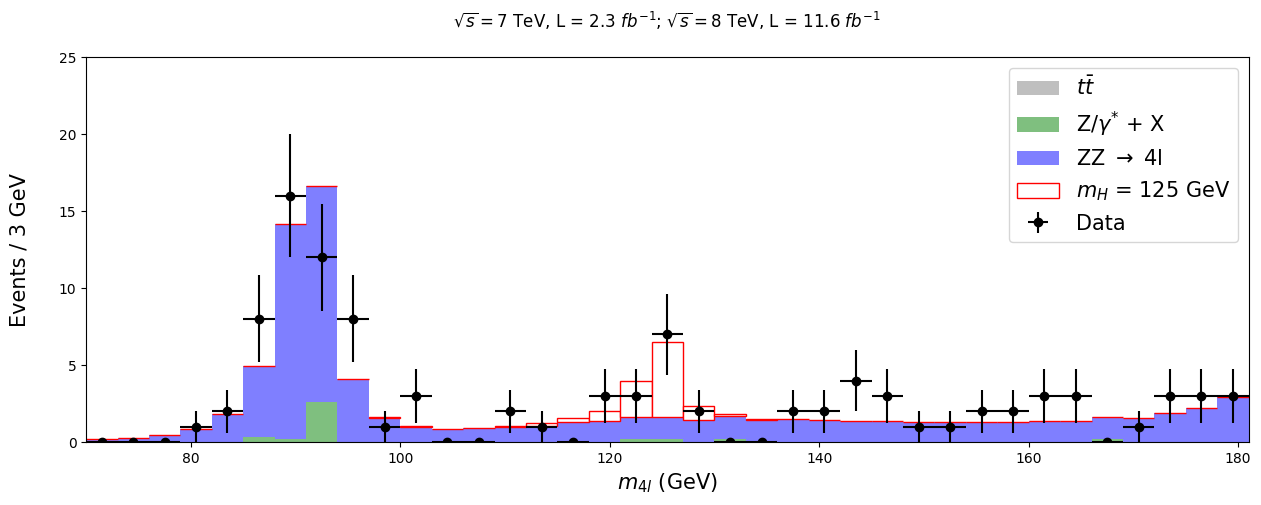

In [18]:
plt.figure(figsize = (15,5))

xerrs = [width*0.5 for i in range(0, nbins)]
yerrs = np.sqrt(hist)

# ttbar 
ttbar_bar = plt.bar(center, ttbar, align = 'center', width = width, color = 'gray', linewidth = 0, edgecolor = 'b',
                    alpha = 0.5, label = r'$t\bar{t}$')

# DY
dy_bar = plt.bar(center, dy, align = 'center', width = width, color = 'g', linewidth = 0, edgecolor = 'black',
                 alpha = 0.5, bottom = ttbar, label = 'Z/$\gamma^{*}$ + X')

# ZZ
zz_bar = plt.bar(center, zz, align = 'center', width = width, color = 'b', linewidth = 0, edgecolor = 'black',
                 alpha = 0.5, bottom = ttbar+dy, label = r'ZZ $\rightarrow$ 4l')


# HZZ
#hzz_bar = plt.bar(center, hzz, align = 'center', width = width, color = 'w', linewidth = 1, edgecolor = 'r', bottom = ttbar+dy+zz, label = r'$m_{H}$ = 125 GeV')


# Measured data
data_bar = plt.errorbar(center, hist, xerr = xerrs, yerr = yerrs, linestyle = 'None', color = 'black',
                        marker = 'o', label = 'Data')

plt.title('$ \sqrt{s} = 7$ TeV, L = 2.3 $fb^{-1}$; $\sqrt{s} = 8$ TeV, L = 11.6 $fb^{-1}$ \n', fontsize = 12)
plt.xlabel('$m_{4l}$ (GeV)', fontsize = 15)
plt.ylabel('Events / 3 GeV\n', fontsize = 15)
plt.ylim(0,25)
plt.xlim(rmin,rmax)
plt.legend(fontsize = 15)

plt.show()

Bevor Sie fortfahren, füllen Sie bitte das Presemo-Formular aus, das Sie [hier](https://presemo.helsinki.fi/bsph2006) finden.
Ein QR-Code dorthing und ein Screenshot der Frage sind unten zu sehen.


<img src = 'https://cern.ch/kirschen/Presemo2_qr-code.png' align = 'center' width="400">

[![Presemo2](https://cern.ch/kirschen/Presemo2_deu.png)](https://presemo.helsinki.fi/bsph2006)

















Es gibt eindeutig einige Punkte, die nicht perfekt zu den simulierten Prozessen passen. Einer fällt besonders heraus. Wir haben einen simulierten Prozess mit vorberechneten Daten ausgelassen, den wir dem Diagramm hinzufügen können. 

Für diese kleine Vorführung reicht es das "#"-Zeichen in der entsprechenden Code-Zeile zu entfernen.

Dieser Datensatz ist zu klein, um etwas mit Sicherheit sagen zu können, aber er weicht nicht allzu sehr von den tatsächlichen Analyseergebnissen ab. Vgl. das offizielle Ergebnis in diesem Kanal, der für die Higgs-Entdeckung verwendet wurde, unten und eine Animation in den Folien.
<img src = 'http://cds.cern.ch/record/1471016/files/H4l_mass_v3.png' align = 'right'>
